# CS 136 day02 Lecture Notebook: Bernoulli distributions and ML estimation


In [ ]:
import numpy as np
import scipy.stats
import time
import warnings
warnings.filterwarnings(action='ignore')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)

# Part 1: Numerical explorations

Imagine we have a dataset of $N/2$ 1s followed by $N/2$ 0s. Let's compute the likelihood of this data under a Bernoulli distribution.

\begin{align}
p( x_1, \ldots x_N) &= \prod_{n=1}^{N/2} \mu \times\prod_{n=N/2}^{N} (1-\mu) 
\\ \\
&= \mu^{N/2} (1-\mu)^{N/2}
\end{align}

Let's try to compute this likelihood for $\mu=0.5$ and $\mu=0.9$ at various values of $N$ (which likelihood do you expect to be larger at every $N$?)

In [ ]:
FLOAT_DTYPE = np.float32
prob = 0.9

mu = np.asarray(prob, FLOAT_DTYPE)
one_minus_mu = np.asarray(1-prob, FLOAT_DTYPE)

### First attempt: Use star-star operator (**)

In [ ]:
for N in [10, 100, 1000]:
    print(mu ** (N/2) * (1-mu)**(N/2))

5.904906e-06
0.0
0.0


### What if we use np.power instead?

In [ ]:
for N in [10, 100, 1000]:
    print(np.power(mu,N/2) * np.power(1-mu,N/2))

5.904906e-06
0.0
0.0


### What is the problem here? How does the likelihood of 0.9 compare to 0.5 at various dataset sizes?

Try changing the value of mu and see how the probabilities change.

### Is the problem solving by using np.float64?

Run the code above with a higher float precision and see what happens.

# Part 2: Numerical explorations with log


Now we'll consider tracking the *natural log* of probability above. 

\begin{align}
\log p( x_1, \ldots x_N) &= \log \bigg(\prod_{n=1}^{N/2} \mu \times\prod_{n=N/2}^{N} (1-\mu)\bigg) 
\\ \\
&= \sum_{n=1}^{N/2} \log\mu +\sum_{n=N/2}^{N} \log(1-\mu)
\\ \\
&= \frac{N}{2} \log\mu + \frac{N}{2} \log(1-\mu)
\end{align}

Let's try to compute this log likelihood for $\mu=0.5$ and $\mu=0.9$ at various values of $N$.

In [ ]:
for N in [10, 100, 1000]:
    print((N/2) * np.log(mu) + (N/2) * np.log(1-mu))

-12.039727
-120.39727
-1203.9728


In [ ]:
np.exp(-1203)

np.float64(0.0)

# Part 3: Computing the log likelihood of a Bernoulli

Two ways to write the formula for a Bernoulli's log PMF mathematically

\begin{align}
\log p( x | \mu) &= \begin{cases}
\log \mu & ~\text{if}~ x =1
\\
\log (1-\mu) & ~\text{if}~ x =0
\end{cases} && \text{A: Selected case only}
\\
&= x \log \mu + (1-x) \log (1-\mu) && \text{B: Weighted product of cases}
\end{align}

Now, while these are equivalent mathematically, they may each have different properties when implemented in code.

What do you think are the pros and cons of implementing each of the two views of the formula above?

## Implementations with forloop

We'll first implement formulas A and B using for loops to traverse a large dataset of size $N$

In [ ]:
def calc_bern_log_pmf__A_forloop(x_N, mu):
    ''' Compute bernoulli log PMF of dataset at given parameter
    
    Args
    ----
    x_N : 1D array of type int32
        Contains binary values
    mu : scalar float, between 0.0 and 1.0
        Probability of the positive outcome in Bern model
        
    Returns
    -------
    logpmf : scalar float
        Log probability of the entire dataset of N points
    '''
    logpmf = 0.0
    N = x_N.size
    for n in range(N):
        if x_N[n] == 1:
            logpmf += np.log(mu)
        else:
            logpmf += np.log(1-mu)
    return logpmf

In [ ]:
def calc_bern_log_pmf__B_forloop(x_N, mu):
    ''' Compute bernoulli log PMF of dataset at given parameter
    
    Args
    ----
    x_N : 1D array of type int32
        Contains binary values
    mu : scalar float, between 0.0 and 1.0
        Probability of the positive outcome in Bern model
        
    Returns
    -------
    logpmf : scalar float
        Log probability of the entire dataset of N points
    '''
    logpmf = 0.0
    N = x_N.size
    for n in range(N):
        logpmf += np.log(mu) * x_N[n] + np.log(1-mu) * (1-x_N[n])
    return logpmf

## Implementations with vectorization

We'll now implement formulas A and B using **vectorized** numpy code for a dataset of size $N$.

This code has NO PYTHON-LEVEL LOOPS. Instead, the work done in the "loop" is performed in compiled routines like `np.sum`, so that the work is done very fast.

In [ ]:
def calc_bern_log_pmf__A_vectorized(x_N, mu):
    ''' Compute bernoulli log PMF of dataset at given parameter
    
    Args
    ----
    x_N : 1D array of type int32
        Contains binary values
    mu : scalar float, between 0.0 and 1.0
        Probability of the positive outcome in Bern model
        
    Returns
    -------
    logpmf : scalar float
        Log probability of the entire dataset of N points
    '''
    count1 = np.sum(x_N==1)
    count0 = np.sum(x_N==0)
    logpmf = 0.0
    if count1 > 0:
        logpmf += count1 * np.log(mu) 
    if count0 > 0:
        logpmf += count0 * np.log(1-mu)
    return logpmf

In [ ]:
def calc_bern_log_pmf__B_vectorized(x_N, mu):
    ''' Compute bernoulli log PMF of dataset at given parameter
    
    Args
    ----
    x_N : 1D array of type int32
        Contains binary values
    mu : scalar float, between 0.0 and 1.0
        Probability of the positive outcome in Bern model
        
    Returns
    -------
    logpmf : scalar float
        Log probability of the entire dataset of N points
    '''
    logpmf = np.sum(x_N * np.log(mu) + (1-x_N) * np.log(1-mu))
    return logpmf


Let's ask each of the 4 functions above for the logpmf of the same dataset with same mu value.

We should observe the *same* logpmf return value if the 4 implementations are each correct.

### Verify correctness with N=20 and mu = 0.5


In [ ]:
prng = np.random.RandomState(101)
x_N = prng.choice(2, size=20)
mu = 0.5

print("x_N:" + str(x_N))

formula_types = ['A', 'B']
loop_types = ['forloop', 'vectorized']
for loop in loop_types:
    for formula in formula_types:
        # ask Python for the function in local workspace with the provided name
        calc_bern_log_lik = locals()['calc_bern_log_pmf__%s_%s' % (formula, loop)]
        print(calc_bern_log_lik(x_N, mu), calc_bern_log_lik.__name__)

x_N:[1 1 1 0 1 1 1 1 1 1 1 0 0 1 0 1 0 0 0 0]
-13.862943611198906 calc_bern_log_pmf__A_forloop
-13.862943611198906 calc_bern_log_pmf__B_forloop
-13.862943611198904 calc_bern_log_pmf__A_vectorized
-13.862943611198906 calc_bern_log_pmf__B_vectorized


### Verify correctness with N=30 and mu = 0.345

In [ ]:
prng = np.random.RandomState(202)
x_N = prng.choice(2, size=30)
mu = 0.345

print("x_N:" + str(x_N))

formula_types = ['A', 'B']
loop_types = ['forloop', 'vectorized']
for loop in loop_types:
    for formula in formula_types:
        # ask Python for the function in local workspace with the provided name
        calc_bern_log_lik = locals()['calc_bern_log_pmf__%s_%s' % (formula, loop)]
        print(calc_bern_log_lik(x_N, mu), calc_bern_log_lik.__name__)

x_N:[1 1 0 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 1 0 1 1 0 0 0 1 1 1 0]
-22.309963579464924 calc_bern_log_pmf__A_forloop
-22.309963579464924 calc_bern_log_pmf__B_forloop
-22.309963579464934 calc_bern_log_pmf__A_vectorized
-22.30996357946493 calc_bern_log_pmf__B_vectorized


## Assess speed of each implementation on large datasets

We'll take the median of 30 trials for each function, to be sure that we get "typical" timing not an outlier.

In [ ]:
n_trials = 30
N = 10000

prng = np.random.RandomState(101)
x_N = prng.choice(2, size=N)
mu = 0.345

print("x_N:" + str(x_N))

formula_types = ['A', 'B']
loop_types = ['forloop', 'vectorized']
for loop in loop_types:
    for formula in formula_types:
        # ask Python for the function in local workspace with the provided name
        calc_bern_log_lik = locals()['calc_bern_log_pmf__%s_%s' % (formula, loop)]
        
        runtimes_in_millisec = list()
        for rep in range(n_trials):
            start_time_millisec = time.time() * 1000
            ans = calc_bern_log_lik(x_N, mu)
            elapsed_time_millisec = time.time() * 1000 - start_time_millisec
            runtimes_in_millisec.append(elapsed_time_millisec)
            
        time_str = "% 11.3f milliseconds" % (np.median(runtimes_in_millisec))
        print(time_str, calc_bern_log_lik.__name__)

x_N:[1 1 1 ... 1 1 1]
      1.483 milliseconds calc_bern_log_pmf__A_forloop
      3.755 milliseconds calc_bern_log_pmf__B_forloop


      0.010 milliseconds calc_bern_log_pmf__A_vectorized
      0.017 milliseconds calc_bern_log_pmf__B_vectorized


# Part 4: Visualizing the log likelihood as a function of parameter $\mu$ 

## Draw fake data from our model

In [ ]:
# Define a random generator object, with specific seed for reproducibility
prng = np.random.RandomState(101)

# Settings
N = 100000   # num bit values to observe

# Pick a "true" mu value for data generation
true_mu = 0.789

# Sample N examples from Bernoulli given mu
x_N = scipy.stats.bernoulli(true_mu).rvs(size=N, random_state=prng)

In [ ]:
# Print first 20 values of data...
x_N[:20]

array([1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1])

## Plot of log likelihood PMF value as a function of parameter mu

We'll make a separate plot as we see more and more data (1 trial, 3 trials, 10 trials, ...)

We evaluate the log likelihood at a dense grid of $\mu$ values, and report the $\mu$ value with the best likelihood below each plot.

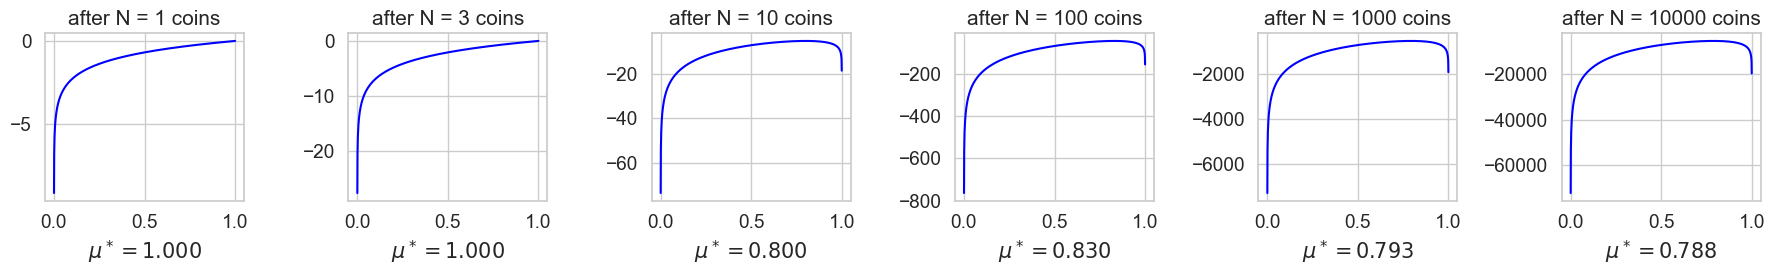

In [ ]:
Npartial_list = [1, 3, 10, 100, 1000, 10000]
L = len(Npartial_list)

fig, axgrid = plt.subplots(
    nrows=1, ncols=L,
    sharex=True, sharey=False,
    figsize=(3 * L, 3))

# Define a grid of mu values at which we'll evaluate the likelihood
G = 1001
mu_grid_G = np.linspace(0.0001, 0.9999, G)

for aa, Npartial in enumerate(Npartial_list):

    log_lik_G = np.zeros(G)
    for gg in range(G):
        log_lik_G[gg] = calc_bern_log_pmf__A_vectorized(x_N[:Npartial], mu_grid_G[gg])
                                    
    axgrid[aa].plot(mu_grid_G, log_lik_G, 'b-')
    axgrid[aa].set_title("after N = %d coins" % Npartial)

    ggstar = np.argmax(log_lik_G)
    mustar = mu_grid_G[ggstar]
    axgrid[aa].set_xlabel(r"$\mu^* = %.3f$" % mustar)
    
plt.tight_layout();